In [1]:
import torch
import supervision
import transformers
import pytorch_lightning
from pathlib import Path
from PIL import Image

/home/ncaytuir/miniconda3/envs/archaia/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Inference with pre-trained COCO model

In [2]:
from transformers import DetrForObjectDetection, DetrImageProcessor

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
CHECKPOINT = 'facebook/detr-resnet-50'
CONFIDENCE_TRESHOLD = 0.5
IOU_TRESHOLD = 0.8

image_processor = DetrImageProcessor.from_pretrained(CHECKPOINT)
model = DetrForObjectDetection.from_pretrained(CHECKPOINT)
model.to(device)

/home/ncaytuir/miniconda3/envs/archaia/lib/python3.10/site-packages/torch/nn/modules/module.py:2400: UserWarning: for conv1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
/home/ncaytuir/miniconda3/envs/archaia/lib/python3.10/site-packages/torch/nn/modules/module.py:2400: UserWarning: for bn1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
/home/ncaytuir/miniconda3/envs/archaia/lib/python3.10/site-packages/torch/nn/modules/module.py:2400: UserWarning: for bn1.bias: copying from a non-meta parameter in the checkpo

DetrForObjectDetection(
  (model): DetrModel(
    (backbone): DetrConvModel(
      (conv_encoder): DetrConvEncoder(
        (model): FeatureListNet(
          (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
          (bn1): DetrFrozenBatchNorm2d()
          (act1): ReLU(inplace=True)
          (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
          (layer1): Sequential(
            (0): Bottleneck(
              (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
              (bn1): DetrFrozenBatchNorm2d()
              (act1): ReLU(inplace=True)
              (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
              (bn2): DetrFrozenBatchNorm2d()
              (drop_block): Identity()
              (act2): ReLU(inplace=True)
              (aa): Identity()
              (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      

{'scores': tensor([], device='cuda:0'), 'labels': tensor([], device='cuda:0', dtype=torch.int64), 'boxes': tensor([], device='cuda:0', size=(0, 4))}


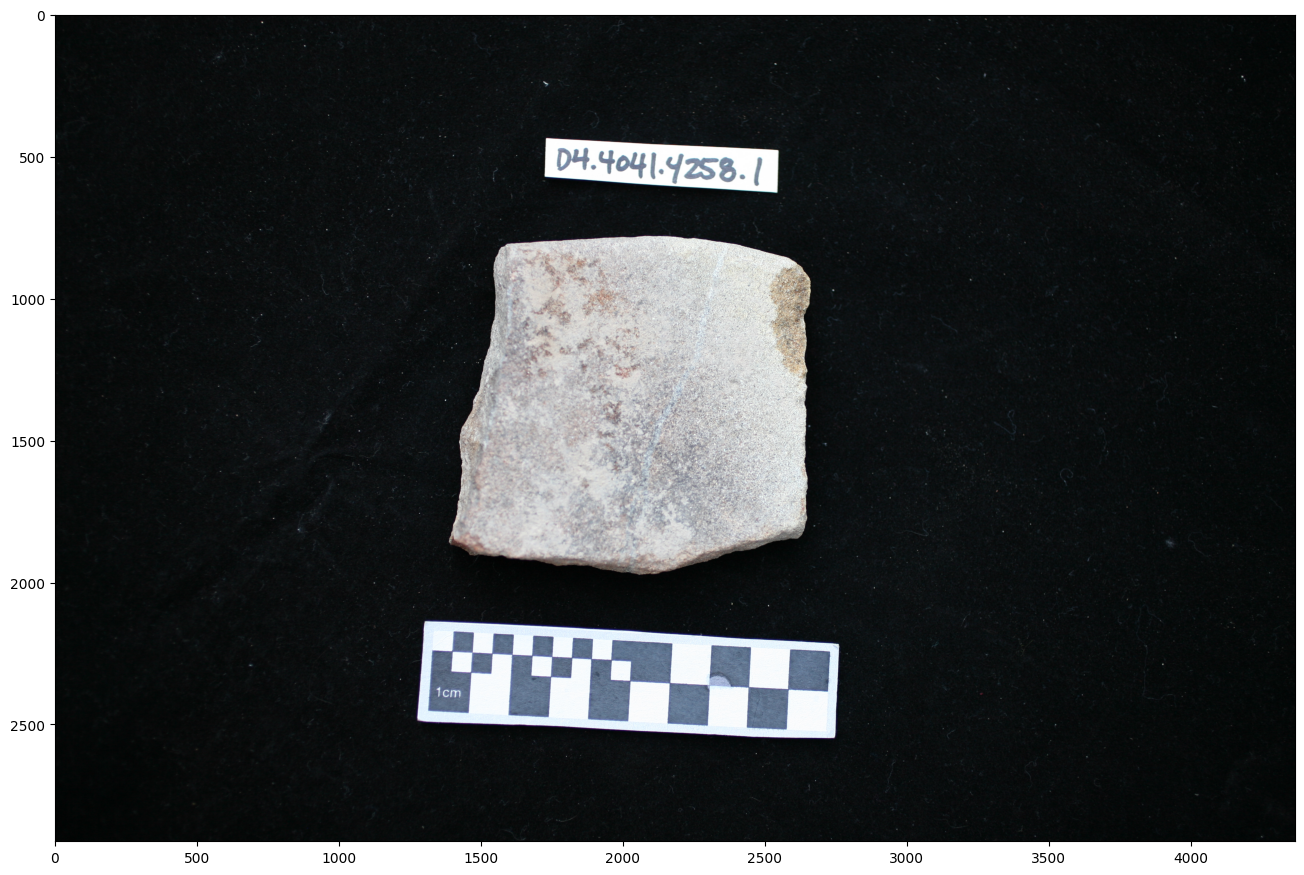

In [3]:
import cv2
import torch
import supervision as sv 

image_path = "/home/ncaytuir/data/ArchaIA_Project/OpenContextData/artifact_0001.jpg"
#image_path = "/home/ncaytuir/data/ArchaIA_Project/OpenContextData/artifact_0007.jpg"

with torch.no_grad():
    # Load the image and predict
    image = cv2.imread(image_path)
    inputs = image_processor(images=image, return_tensors='pt').to(device)
    outputs = model(**inputs)

    # Post-process
    target_sizes = torch.tensor([image.shape[:2]]).to(device)
    results = image_processor.post_process_object_detection(outputs=outputs, threshold=CONFIDENCE_TRESHOLD, target_sizes=target_sizes)[0]
    print(results)

# Anotate
detections = sv.Detections.from_transformers(transformers_results=results)

labels = [
    f"{model.config.id2label[class_id]} {confidence:0.2f}" 
    for _, confidence, class_id, _ 
    in detections
]

box_annotator = sv.BoxAnnotator()
frame = box_annotator.annotate(scene=image, detections=detections, labels=labels)

%matplotlib inline
sv.show_frame_in_notebook(frame, (16, 16))

Load COCO annotations

In [ ]:
import json

ANNOTATIONS_PATH = "/home/ncaytuir/data/ArchaIA_Project/DETRDataset/result.json"
IMAGES_DIR = "/home/ncaytuir/data/ArchaIA_Project/FilteredData"

with open(ANNOTATIONS_PATH) as f:
    coco_data = json.load(f)

images = coco_data['images']
annotations = coco_data['annotations']
categories = coco_data['categories']

# Map category_id to name
id2label = {cat["id"]: cat["name"] for cat in categories}
label2id = {v: k for k, v in id2label.items()}

Visualice some samples

/home/ncaytuir/data/ArchaIA_Project/FilteredData/artifact_0160.jpg


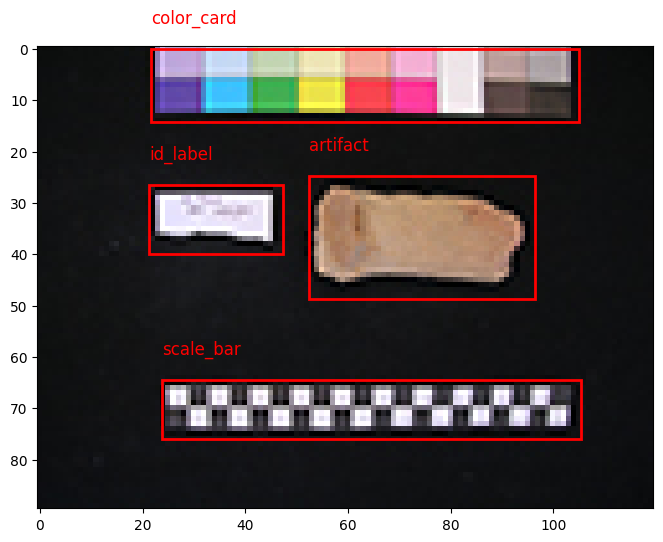

/home/ncaytuir/data/ArchaIA_Project/FilteredData/artifact_0062.jpg


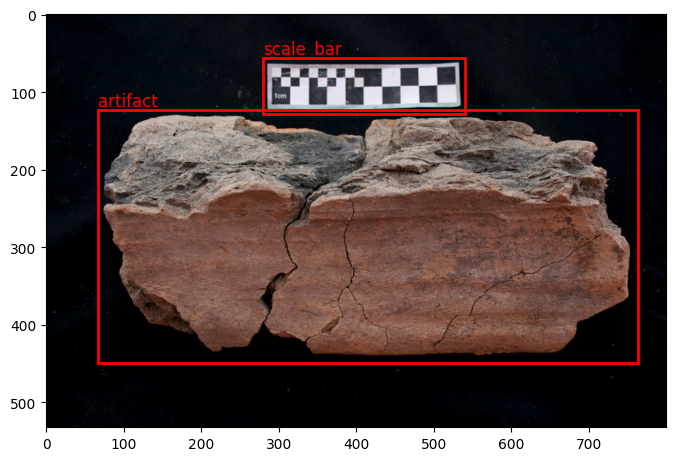

/home/ncaytuir/data/ArchaIA_Project/FilteredData/artifact_0095.jpg


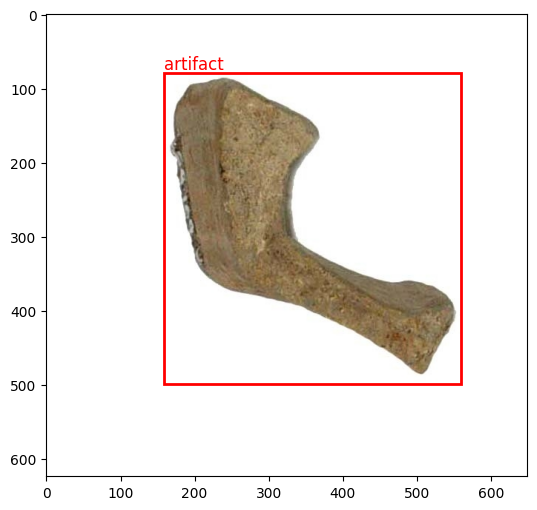

In [5]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import ImageOps

def visualice_random_samples(images, n=3):
    sample_images = random.sample(images, n)

    for img_info in sample_images:
        img_filename = os.path.basename(img_info["file_name"])
        img_path = os.path.join(IMAGES_DIR, img_filename)
        print(img_path)
        image = Image.open(img_path).convert("RGB")
        image = ImageOps.exif_transpose(image).convert("RGB")

        fig, ax = plt.subplots(1, figsize=(8,6))
        ax.imshow(image)

        img_annotations = [ann for ann in annotations if ann["image_id"] == img_info["id"]]

        for ann in img_annotations:
            x, y, w, h = ann["bbox"]
            rect = patches.Rectangle(
                (x, y), w, h,
                linewidth=2,
                edgecolor='red',
                facecolor='none'
            )
            ax.add_patch(rect)
            ax.text(x, y-5, id2label[ann["category_id"]], color='red', fontsize=12)

        plt.show()
    
visualice_random_samples(images, 3)

Split dataset

In [6]:
import random

random.seed(42)

image_ids = [img["id"] for img in images]
random.shuffle(image_ids)

split_idx = int(0.8 * len (image_ids))

train_ids = set(image_ids[:split_idx])
val_ids = set(image_ids[split_idx:])

train_images = [img for img in images if img["id"] in train_ids]
val_images = [img for img in images if img["id"] in val_ids]

train_annotations = [ann for ann in annotations if ann["image_id"] in train_ids]
val_annotations = [ann for ann in annotations if ann["image_id"] in val_ids]

print(f"Train: {len(train_images)} images")
print(f"Val: {len(val_images)} images")

Train: 65 images
Val: 17 images


Create the dataset

In [7]:
from torch.utils.data import Dataset, DataLoader

class CreateDataset(Dataset):
    def __init__(self, images, annotations, image_dir, processor):
        self.images = images
        self.annotations = annotations
        self.image_dir = image_dir
        self.processor = processor

        self.image_id_to_annotations = {}
        for ann in annotations:
            self.image_id_to_annotations.setdefault(ann["image_id"], []).append(ann)
    
    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        img_info = self.images[index]
        img_filename = os.path.basename(img_info["file_name"])
        img_path = os.path.join(IMAGES_DIR, img_filename)
        image = Image.open(img_path).convert("RGB")
        image = ImageOps.exif_transpose(image).convert("RGB")

        anns = self.image_id_to_annotations.get(img_info["id"], [])

        target = {
            "image_id": img_info["id"],
            "annotations": anns
        }

        encoding = self.processor(
            images=image,
            annotations=target,
            return_tensors="pt"
        )

        #pixel_values = encoding["pizel_values"].squeeze()
        #labels = encoding["labels"][0]

        return encoding["pixel_values"].squeeze(), encoding["labels"][0]

In [8]:
from transformers import DetrForObjectDetection, DetrImageProcessor

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
CHECKPOINT = 'facebook/detr-resnet-50'

image_processor = DetrImageProcessor.from_pretrained(CHECKPOINT)

model = DetrForObjectDetection.from_pretrained(
    CHECKPOINT,
    num_labels = len(categories),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

model.to(device)

Some weights of the model checkpoint at facebook/detr-resnet-50 were not used when initializing DetrForObjectDetection: ['model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing DetrForObjectDetection from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DetrForObjectDetection from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of DetrForObjectDetection were not initialized from the model checkpoin

DetrForObjectDetection(
  (model): DetrModel(
    (backbone): DetrConvModel(
      (conv_encoder): DetrConvEncoder(
        (model): FeatureListNet(
          (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
          (bn1): DetrFrozenBatchNorm2d()
          (act1): ReLU(inplace=True)
          (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
          (layer1): Sequential(
            (0): Bottleneck(
              (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
              (bn1): DetrFrozenBatchNorm2d()
              (act1): ReLU(inplace=True)
              (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
              (bn2): DetrFrozenBatchNorm2d()
              (drop_block): Identity()
              (act2): ReLU(inplace=True)
              (aa): Identity()
              (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      

Create data loaders

In [9]:
def collate_fn(batch):
    pixel_values = [item[0] for item in batch]
    labels = [item[1] for item in batch]

    encoding = image_processor.pad(pixel_values, return_tensors="pt")
    return {
        "pixel_values": encoding["pixel_values"],
        "pixel_mask": encoding["pixel_mask"],
        "labels": labels
    }

train_dataset = CreateDataset(train_images, train_annotations, IMAGES_DIR, image_processor)
val_dataset = CreateDataset(val_images, val_annotations, IMAGES_DIR, image_processor)

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=collate_fn
)

In [10]:
train_dataset[1]

(tensor([[[ 0.0227,  0.0227,  0.0227,  ..., -0.3198, -0.3198, -0.3198],
          [ 0.0227,  0.0227,  0.0227,  ..., -0.3198, -0.3198, -0.3198],
          [ 0.0227,  0.0227,  0.0227,  ..., -0.3198, -0.3198, -0.3198],
          ...,
          [-0.0629, -0.0629, -0.0629,  ..., -0.5424, -0.5424, -0.5424],
          [-0.0629, -0.0629, -0.0629,  ..., -0.5424, -0.5424, -0.5424],
          [-0.0629, -0.0629, -0.0629,  ..., -0.5424, -0.5424, -0.5424]],
 
         [[ 0.1001,  0.1001,  0.1001,  ..., -0.2325, -0.2325, -0.2325],
          [ 0.1001,  0.1001,  0.1001,  ..., -0.2325, -0.2325, -0.2325],
          [ 0.1001,  0.1001,  0.1001,  ..., -0.2325, -0.2325, -0.2325],
          ...,
          [-0.0049, -0.0049, -0.0049,  ..., -0.5301, -0.5301, -0.5301],
          [-0.0049, -0.0049, -0.0049,  ..., -0.5301, -0.5301, -0.5301],
          [-0.0049, -0.0049, -0.0049,  ..., -0.5301, -0.5301, -0.5301]],
 
         [[ 0.1651,  0.1651,  0.1651,  ..., -0.2358, -0.2358, -0.2358],
          [ 0.1651,  0.1651,

In [11]:
empty_images = []

for img in train_images:
    img_id = img["id"]
    anns = [ann for ann in train_annotations if ann["image_id"] == img_id]
    if len(anns) == 0:
        empty_images.append(img_id)

print("Images with NO annotations:", len(empty_images))

Images with NO annotations: 0


In [12]:
import os

bad_images = []

for img in train_images:
    img_id = img["id"]
    anns = [ann for ann in train_annotations if ann["image_id"] == img_id]

    for ann in anns:
        x, y, w, h = ann["bbox"]

        if w <= 0 or h <= 0:
            bad_images.append(img_id)

print("Images with invalid boxes:", len(set(bad_images)))

Images with invalid boxes: 0


Fine-tune the model

In [15]:
from torchvision.ops import box_convert
from torchmetrics.detection.mean_ap import MeanAveragePrecision

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)
metric = MeanAveragePrecision(iou_type="bbox")

EPOCHS = 30

for epoch in range(EPOCHS):
    # Train
    model.train()
    total_loss = 0

    for batch in train_loader:
        pixel_values = batch["pixel_values"].to(device)
        pixel_mask = batch["pixel_mask"].to(device)
        labels = [{k: v.to(device) for k, v in t.items()} for t in batch["labels"]]

        outputs = model(pixel_values=pixel_values, pixel_mask=pixel_mask, labels=labels)

        loss = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    
    avg_train_loss = total_loss / len(train_loader)

    # Validation
    model.eval()
    metric.reset()

    with torch.no_grad():
        for batch in val_loader:
            pixel_values = batch["pixel_values"].to(device)
            pixel_mask = batch["pixel_mask"].to(device)

            outputs = model(pixel_values=pixel_values, pixel_mask=pixel_mask)

            target_sizes = torch.stack([
                torch.tensor(label["orig_size"])
                for label in batch["labels"]
            ]).to(device)

            results = image_processor.post_process_object_detection(
                outputs, target_sizes=target_sizes, threshold=0.5
            )

            preds = []
            targets = []

            for i, result in enumerate(results):
                preds.append({
                    "boxes": result["boxes"].cpu(),
                    "scores": result["scores"].cpu(),
                    "labels": result["labels"].cpu()
                })

                targets.append({
                    "boxes": batch["labels"][i]["boxes"].cpu(),
                    "labels": batch["labels"][i]["class_labels"].cpu()
                })
            
            metric.update(preds, targets)

    metrics = metric.compute()

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {avg_train_loss:.4f}")
    print(f"mAP: {metrics['map']:.4f}")
    print("-"*40)


/tmp/ipykernel_3010150/2212873205.py:43: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(label["orig_size"])


Epoch 1
Train Loss: 2.5255
mAP: 0.0000
----------------------------------------
Epoch 2
Train Loss: 1.9443
mAP: 0.0000
----------------------------------------
Epoch 3
Train Loss: 1.5691
mAP: 0.0000
----------------------------------------
Epoch 4
Train Loss: 1.9113
mAP: 0.0000
----------------------------------------
Epoch 5
Train Loss: 1.8960
mAP: 0.0000
----------------------------------------
Epoch 6
Train Loss: 1.6483
mAP: 0.0000
----------------------------------------
Epoch 7
Train Loss: 2.8076
mAP: 0.0000
----------------------------------------
Epoch 8
Train Loss: 2.5139
mAP: 0.0000
----------------------------------------
Epoch 9
Train Loss: 1.8527
mAP: 0.0000
----------------------------------------
Epoch 10
Train Loss: 1.8513
mAP: 0.0000
----------------------------------------
Epoch 11
Train Loss: 2.6110
mAP: 0.0000
----------------------------------------
Epoch 12
Train Loss: 1.8117
mAP: 0.0000
----------------------------------------
Epoch 13
Train Loss: 1.4490
mAP: 0.00

In [ ]:
model.save_pretrained("./detr-archaeology")
image_processor.save_pretrained("./detr-archaeology")